## Two-Dimensional Shastry–Sutherland Model
#### Thermodynamic properties of the Shastry-Sutherland model throughout the dimer-product phase
#### https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.1.033038
#### c.f. 19.2.1.3 on page 520 in Lacroix et al - Introduction to frustrated magnetism (2011)

In [1]:
include("../QMC.jl")
include("../QMC_plot.jl")
include("../Lattice.jl")

erdos_renyi (generic function with 1 method)

In [2]:
#ShastrySutherland2D(2,2, periodic=true)
get(reverse(ColorSchemes.colorschemes[:RdYlBu]), 0)
reverse(ColorSchemes.colorschemes[:diverging_linear_bjy_30_90_c45_n256])
reverse(ColorSchemes.colorschemes[:RdYlBu])

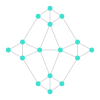

In [3]:
#Check correctness of lattice
A = shastry_sutherland2D(2,2;J=1,J_diag=-1, periodic=false)
g = Graphs.SimpleGraph(A)
import GraphPlot
GraphPlot.gplot(g, layout=GraphPlot.spectral_layout)

## Dimer - Plaquette - Neel phases from Wietek et al: SOCP and SOCP + NPA-Pauli1 has gives same energy
#### https://journals.aps.org/prresearch/pdf/10.1103/PhysRevResearch.1.033038

In [4]:
import Cairo # Cairo is needed for Compose.PDF
import Compose #import Cairo

In [5]:
l = h = 4
J_diag = 1
# open boundary lattice only for plotting
A_open = shastry_sutherland2D(l,h; J=1, J_diag=1, periodic=false); 

In [6]:
# dimer phase: J/JD = 0.45; #J = 0.45

# phase transition dimer - plaquette: J/J_D = 0.725 #J = 0.5
# here: exactly at 0.5 the plaquette-Neel transition happens

# Neel phase: J/JD = 0.9; #J = 0.6

0.45 / 1  -46.39999999999981

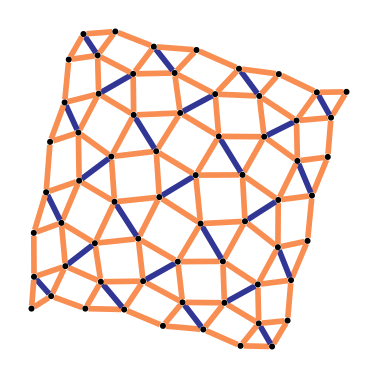

In [7]:
J = 0.45
solver="mosek"

print(J," / ", J_diag, "  ")
A = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true);
val, X = QMC_SOC(A, verbose=false, pauli_NPA1=false, solver=solver)
plot = QMC_Plot(A_open,X)
name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * ".pdf"
Compose.draw(Compose.PDF(name, 16Compose.cm, 16Compose.cm), plot) #print to file
print(val); plot

### test: same but with selected 4-RDMs (too large for my laptop)

0.45 / 1  -46.39999918061702

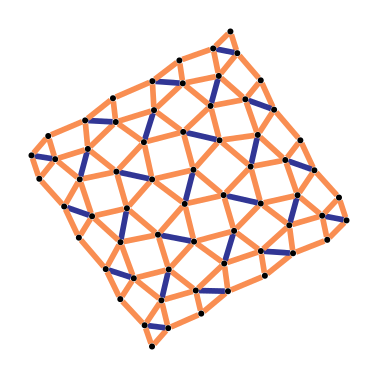

In [8]:
J = 0.45
solver="mosek"

FS = shastry_sutherland2D_4RDM(l,h)
print(J," / ", J_diag, "  ")
A = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true);
val, X = QMC_SOC(A, verbose=false, pauli_NPA1=false, four_qb = FS, solver=solver)
plot = QMC_Plot(A_open,X)
#name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * ".pdf"
#Compose.draw(Compose.PDF(name, 16Compose.cm, 16Compose.cm), plot) #print to file
print(val); plot

### back to phase transition

In [ ]:
J = 0.5

print(J," / ", J_diag, "  ")
A = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true);
val, X = QMC_SOC(A, verbose=false, pauli_NPA1=false)
plot = QMC_Plot(A_open,X)
name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * ".pdf"
Compose.draw(Compose.PDF(name, 16Compose.cm, 16Compose.cm), plot) #print to file
print(val); plot

In [ ]:
J = 0.6

print(J," / ", J_diag, "  ")
A = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true);
val, X = QMC_SOC(A, verbose=false, pauli_NPA1=false)
plot = QMC_Plot(A_open,X)
name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * ".pdf"
Compose.draw(Compose.PDF(name, 16Compose.cm, 16Compose.cm), plot) #print to file
print(val); plot

## Phase transition according to paper be should be at roughly 

In [ ]:
0.675 + (0.765 - 0.675)/2

### with Pauli NPA

In [ ]:
# phase transition dimer - plaquette: J/J_D = 0.72

l = 4
h = 4

# here: exactly at 0.5 the plaquette-Neel transition happens
J = 0.5
J_diag = 1

A      = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true)
A_open = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=false)

val, X = QMC_SOC(A; pauli_NPA1=true, verbose=false)
print(J," / ", J_diag)
plot = QMC_Plot(A_open, X)
name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * "PauliNPA" * ".pdf"
draw(Compose.PDF(name, 16cm, 16cm), plot)
plot

In [ ]:
# phase transition dimer - plaquette: J/J_D = 0.72

l = h = 5

# here: exactly at 0.5 the plaquette-Neel transition happens
J = 0.51
J_diag = 1

A      = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=true)
A_open = shastry_sutherland2D(l,h; J=J, J_diag=J_diag, periodic=false)

val, X = QMC_SOC(A; pauli_NPA1=true, verbose=false)
print(J," / ", J_diag)
plot = QMC_Plot(A_open, X)
name = "ShastrySutherland_" * string(l) * string(h) * "_" * string(J) * ".pdf"
draw(Compose.PDF(name, 16cm, 16cm), plot)
plot